# The Elbow Method

### Overview 

In this lesson we will examine how to perform K-Means clustering use the well-known Iris dataset. When we have completed this lesson, we will proceed to deep dive into the fundamentals of significance testing and data scaling.

## K-Means Clustering

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist

In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
import warnings
warnings.filterwarnings('ignore')

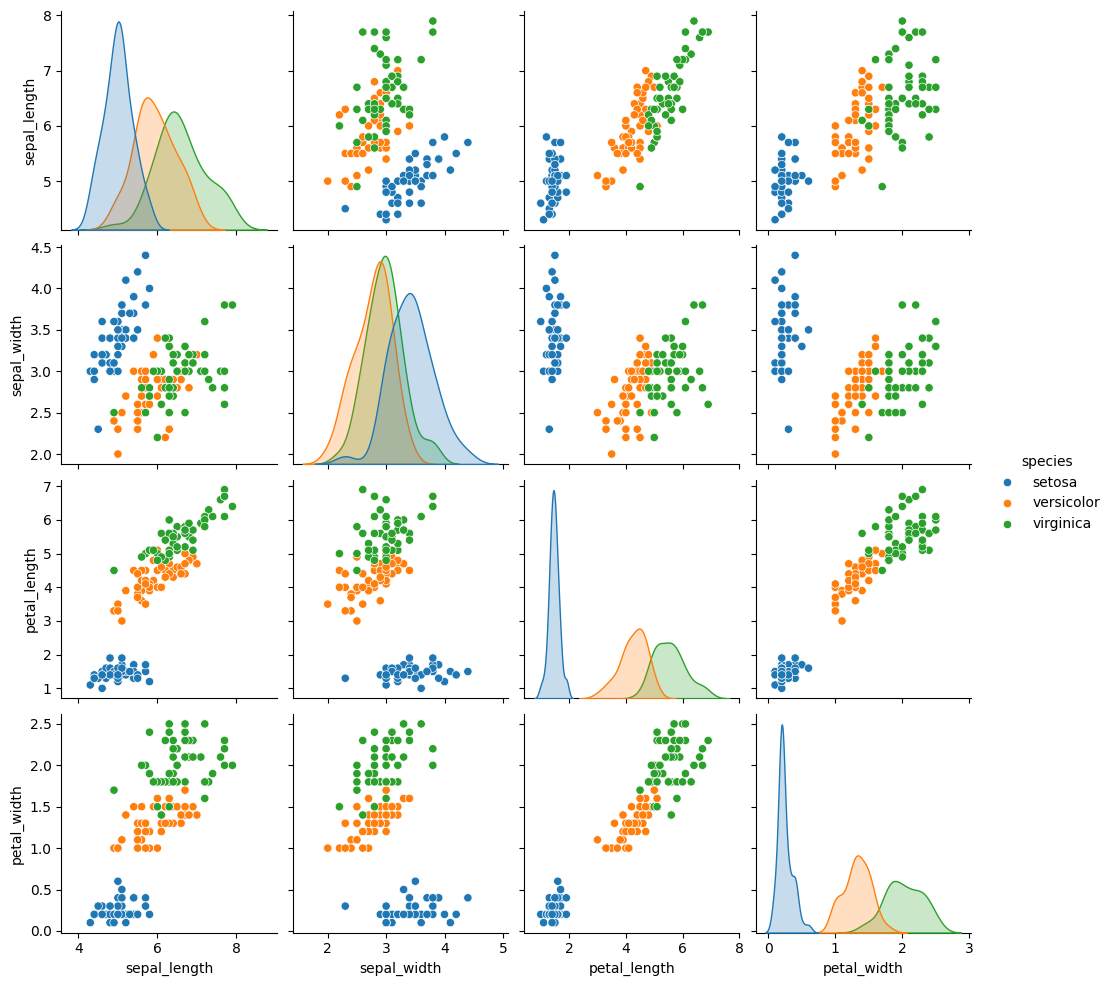

In [4]:
sns.pairplot(iris, hue='species')

##### Scenario: we want to classify the species using the features available.
Imagine we wanted to use this relatively easy to obtain data to classify the species. In this case we are trying to classify a species (as though no one told us), but this could be any scenario where we want to either classify or segment a group. For example:

* Customer segmentation
* Fraud detection
* Identifying colors that best capture an image
* Grouping similar documents together
* etc...

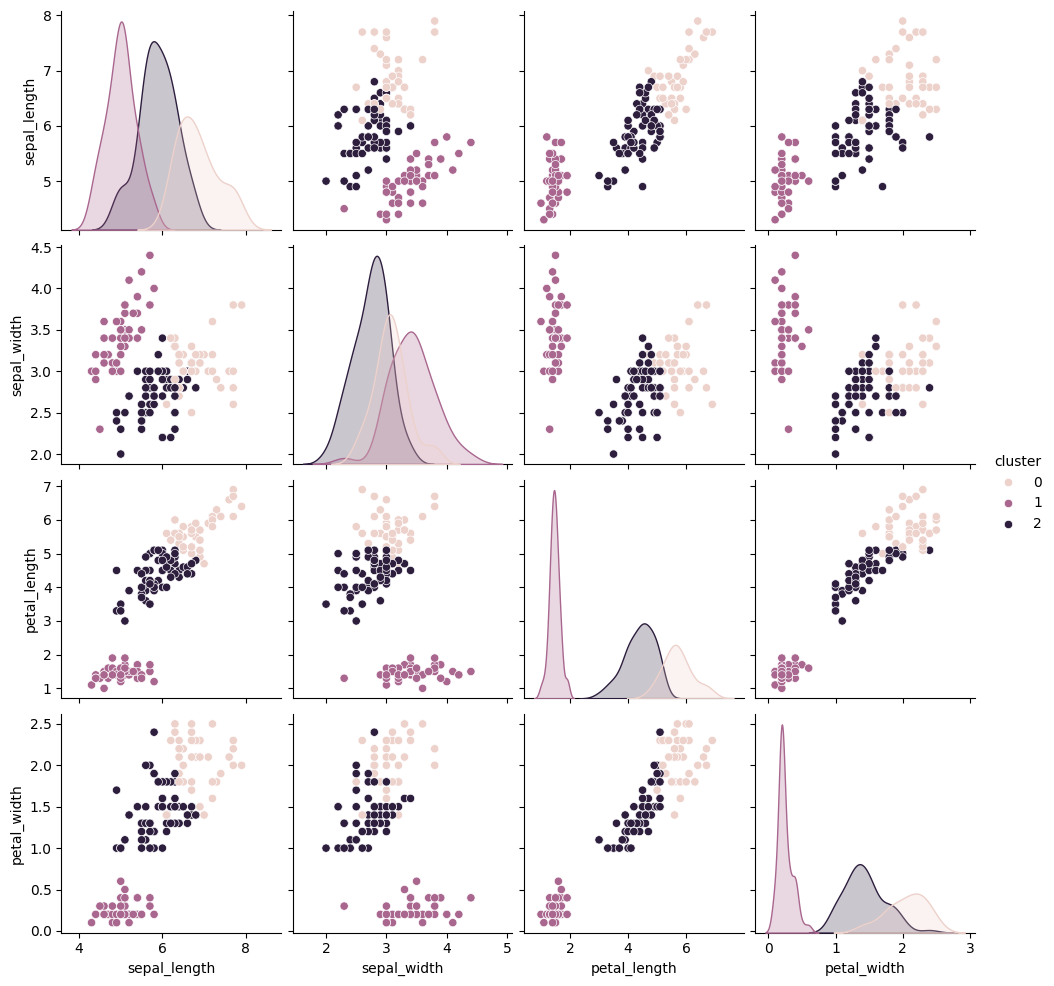

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
X = iris.drop('species', axis=1)
kmeans.fit(X)
iris['cluster'] = kmeans.predict(X)
sns.pairplot(iris, hue='cluster')

### Evaluate the results 

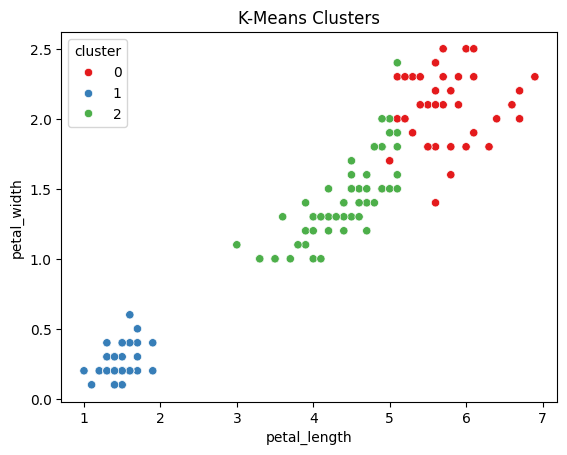

In [8]:
sns.scatterplot(x='petal_length', y='petal_width', data=iris, hue='cluster', palette='Set1')
plt.title('K-Means Clusters')
plt.show()

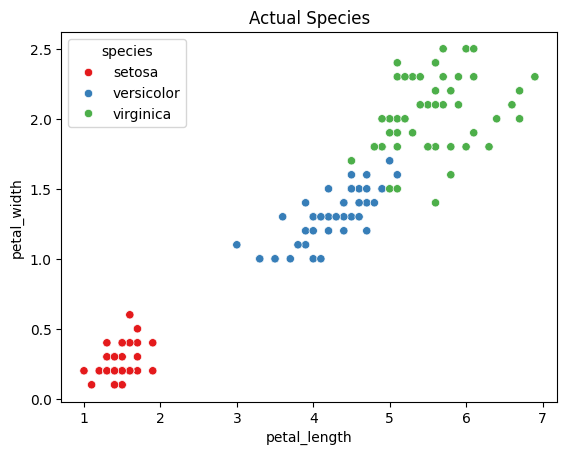

In [9]:
sns.scatterplot(x='petal_length', y='petal_width', data=iris, hue='species', palette='Set1')
plt.title('Actual Species')
plt.show()

In [10]:
pd.crosstab(iris['species'], iris['cluster'])

cluster,0,1,2
species,,,
setosa,0,50,0
versicolor,3,0,47
virginica,36,0,14


**What if we didn't know the number of clusters?**

In [11]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

inertia

[681.3706,
 152.3479517603579,
 78.8556658259773,
 57.35088021295475,
 46.472230158730156,
 39.066035353535355,
 34.3058152958153,
 30.476222943722952,
 29.90624665913797,
 28.545297810033112]

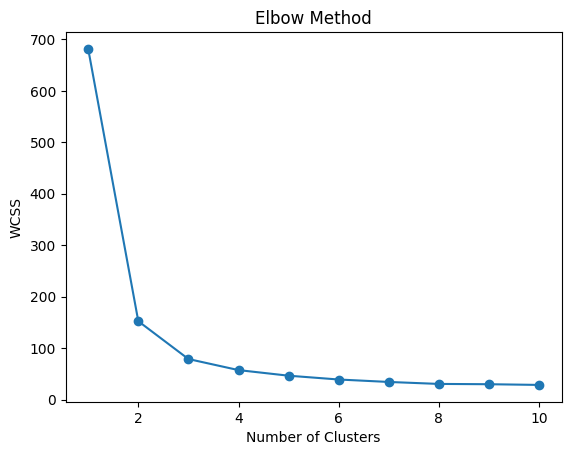

In [17]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()